In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jessicali9530/celeba-dataset/list_landmarks_align_celeba.csv
/kaggle/input/datasets/jessicali9530/celeba-dataset/list_eval_partition.csv
/kaggle/input/datasets/jessicali9530/celeba-dataset/list_attr_celeba.csv
/kaggle/input/datasets/jessicali9530/celeba-dataset/list_bbox_celeba.csv


KeyboardInterrupt: 

In [2]:
import os
import torch

# Check GPU
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

# Check dataset
img_dir = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"
images = os.listdir(img_dir)
print(f"\nTotal images: {len(images)}")
print("Sample filenames:", images[:5])

CUDA available: True
GPU count: 2
GPU name: Tesla T4

Total images: 202599
Sample filenames: ['083648.jpg', '168202.jpg', '125778.jpg', '059339.jpg', '032501.jpg']


## Variational Autoencoder on CelebA
Building a VAE from scratch on 200k celebrity face images. We will:
1. Load and visualize the dataset
2. Build the Encoder, Decoder, and VAE architecture
3. Train with reconstruction loss + KL divergence
4. Explore the latent space — interpolation and generation

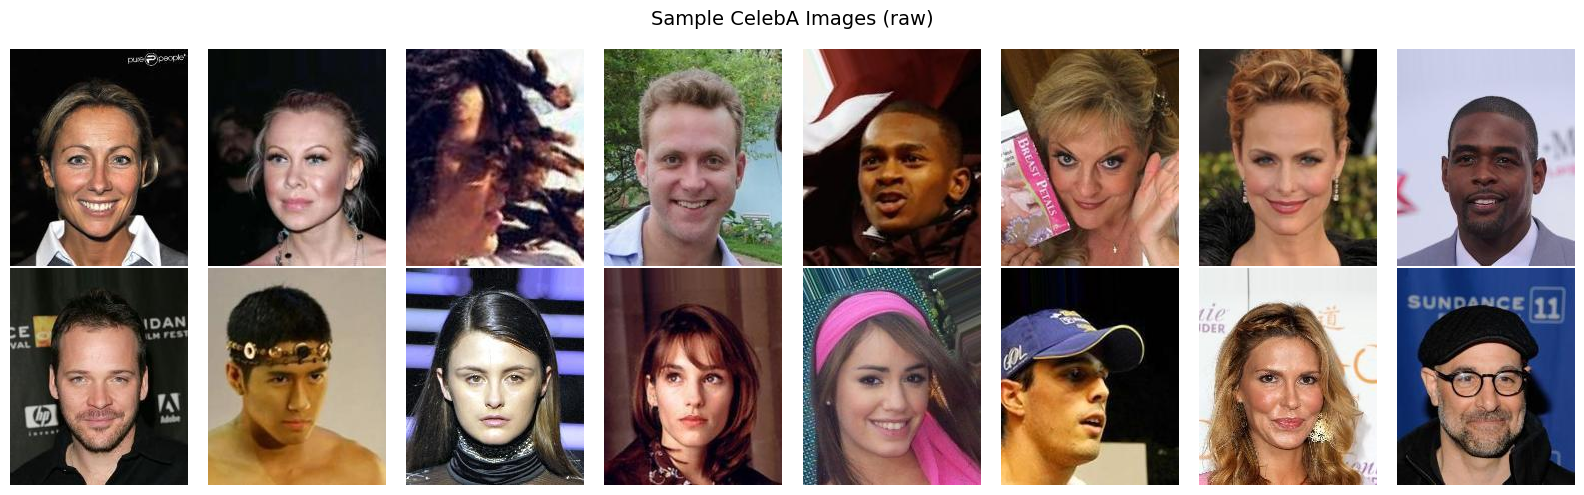

Image size: (178, 218)


In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import random

img_dir = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"
all_images = os.listdir(img_dir)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
sample = random.sample(all_images, 16)

for i, ax in enumerate(axes.flatten()):
    img = Image.open(os.path.join(img_dir, sample[i]))
    ax.imshow(img)
    ax.axis('off')

plt.suptitle("Sample CelebA Images (raw)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Image size: {img.size}")  # width x height

## Step 1: Data Pipeline
Setting up transforms and DataLoader. We resize all images to 64x64 and normalize 
pixel values to [-1, 1] range.

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class CelebADataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.images = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

# Transforms: resize → center crop → tensor → normalize to [-1, 1]
transform = transforms.Compose([
    transforms.Resize(74),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

img_dir = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"

dataset = CelebADataset(img_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)

print(f"Dataset size: {len(dataset)}")
print(f"Total batches: {len(dataloader)}")

# Verify one batch shape
batch = next(iter(dataloader))
print(f"Batch shape: {batch.shape}")
print(f"Pixel value range: [{batch.min():.2f}, {batch.max():.2f}]")

Dataset size: 202599
Total batches: 1583
Batch shape: torch.Size([128, 3, 64, 64])
Pixel value range: [-1.00, 1.00]


## Step 2: VAE Architecture
Building the VAE from scratch with three components:
- **Encoder**: Compresses 64x64 image → mean and log-variance vectors (latent dim = 128)
- **Reparameterization trick**: Samples z = mean + eps * std (makes backprop possible)
- **Decoder**: Reconstructs image from z back to 64x64

In [5]:
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # Input: (B, 3, 64, 64)
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # → (B, 32, 32, 32)
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1),  # → (B, 64, 16, 16)
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), # → (B, 128, 8, 8)
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),# → (B, 256, 4, 4)
            nn.LeakyReLU(0.2),
        )
        self.fc_mu     = nn.Linear(256*4*4, latent_dim)
        self.fc_logvar = nn.Linear(256*4*4, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)   # flatten
        mu     = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256*4*4)
        # Input: (B, 256, 4, 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), # → (B, 128, 8, 8)
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # → (B, 64, 16, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # → (B, 32, 32, 32)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),    # → (B, 3, 64, 64)
            nn.Tanh()  # output in [-1, 1] to match our normalization
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 256, 4, 4)
        return self.deconv(x)


class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        # During training: z = mu + eps*std  (eps ~ N(0,1))
        # During inference: just return mu
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar


# Quick sanity check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE(latent_dim=128).to(device)

dummy = torch.randn(4, 3, 64, 64).to(device)
recon, mu, logvar = model(dummy)

print(f"Input shape:       {dummy.shape}")
print(f"Reconstructed:     {recon.shape}")
print(f"Mu shape:          {mu.shape}")
print(f"Logvar shape:      {logvar.shape}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Input shape:       torch.Size([4, 3, 64, 64])
Reconstructed:     torch.Size([4, 3, 64, 64])
Mu shape:          torch.Size([4, 128])
Logvar shape:      torch.Size([4, 128])

Total parameters: 2,957,251


## VAE Architecture Visualization
Visual summary of the encoder, reparameterization trick, and decoder.

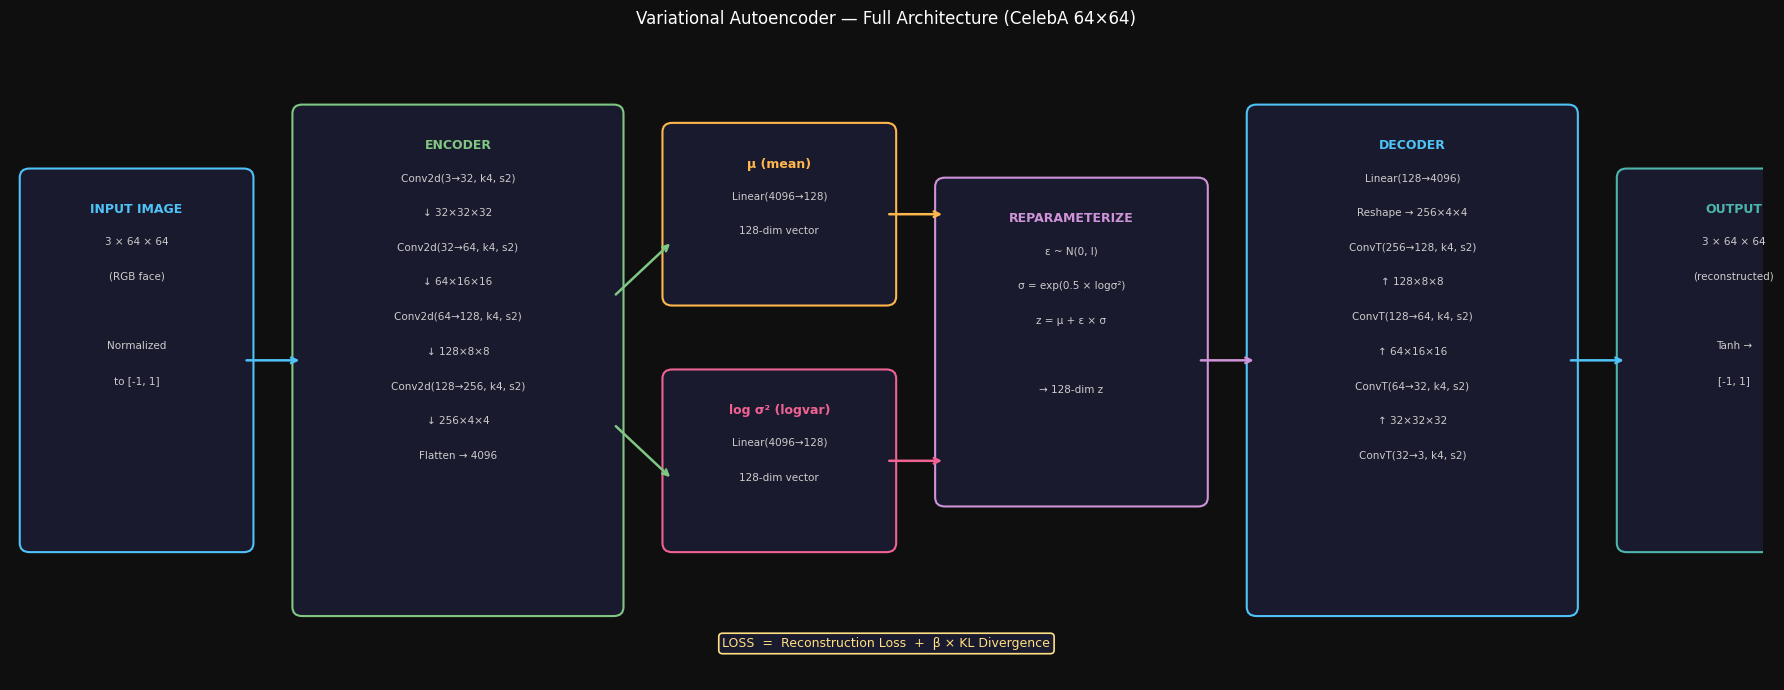

Architecture diagram saved.


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(18, 7))
ax.set_xlim(0, 18)
ax.set_ylim(0, 7)
ax.axis('off')
ax.set_facecolor('#0f0f0f')
fig.patch.set_facecolor('#0f0f0f')

def draw_box(ax, x, y, w, h, title, lines, color):
    rect = mpatches.FancyBboxPatch((x, y), w, h,
        boxstyle="round,pad=0.1", linewidth=1.5,
        edgecolor=color, facecolor='#1a1a2e')
    ax.add_patch(rect)
    ax.text(x + w/2, y + h - 0.28, title,
        ha='center', va='top', fontsize=9, fontweight='bold', color=color)
    for i, line in enumerate(lines):
        ax.text(x + w/2, y + h - 0.65 - i*0.38, line,
            ha='center', va='top', fontsize=7.5, color='#cccccc')

def arrow(ax, x1, y1, x2, y2, color='white'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.8))

# ---- INPUT ----
draw_box(ax, 0.2, 1.5, 2.2, 4.0, 'INPUT IMAGE',
    ['3 × 64 × 64', '(RGB face)', '', 'Normalized', 'to [-1, 1]'], '#4fc3f7')

arrow(ax, 2.4, 3.5, 3.0, 3.5, '#4fc3f7')

# ---- ENCODER ----
draw_box(ax, 3.0, 0.8, 3.2, 5.4, 'ENCODER',
    ['Conv2d(3→32, k4, s2)', '↓ 32×32×32',
     'Conv2d(32→64, k4, s2)', '↓ 64×16×16',
     'Conv2d(64→128, k4, s2)','↓ 128×8×8',
     'Conv2d(128→256, k4, s2)','↓ 256×4×4',
     'Flatten → 4096'], '#81c784')

arrow(ax, 6.2, 4.2, 6.8, 4.8, '#81c784')
arrow(ax, 6.2, 2.8, 6.8, 2.2, '#81c784')

# ---- MU / LOGVAR ----
draw_box(ax, 6.8, 4.2, 2.2, 1.8, 'μ (mean)',
    ['Linear(4096→128)', '128-dim vector'], '#ffb74d')

draw_box(ax, 6.8, 1.5, 2.2, 1.8, 'log σ² (logvar)',
    ['Linear(4096→128)', '128-dim vector'], '#f06292')

arrow(ax, 9.0, 5.1, 9.6, 5.1, '#ffb74d')
arrow(ax, 9.0, 2.4, 9.6, 2.4, '#f06292')

# ---- REPARAMETERIZATION ----
draw_box(ax, 9.6, 2.0, 2.6, 3.4, 'REPARAMETERIZE',
    ['ε ~ N(0, I)',
     'σ = exp(0.5 × logσ²)',
     'z = μ + ε × σ',
     '',
     '→ 128-dim z'], '#ce93d8')

arrow(ax, 12.2, 3.5, 12.8, 3.5, '#ce93d8')

# ---- DECODER ----
draw_box(ax, 12.8, 0.8, 3.2, 5.4, 'DECODER',
    ['Linear(128→4096)',
     'Reshape → 256×4×4',
     'ConvT(256→128, k4, s2)','↑ 128×8×8',
     'ConvT(128→64, k4, s2)', '↑ 64×16×16',
     'ConvT(64→32, k4, s2)',  '↑ 32×32×32',
     'ConvT(32→3, k4, s2)'], '#4fc3f7')

arrow(ax, 16.0, 3.5, 16.6, 3.5, '#4fc3f7')

# ---- OUTPUT ----
draw_box(ax, 16.6, 1.5, 2.2, 4.0, 'OUTPUT',
    ['3 × 64 × 64', '(reconstructed)', '', 'Tanh →', '[-1, 1]'], '#4db6ac')

# ---- LOSS LABEL ----
ax.text(9.0, 0.4, 'LOSS  =  Reconstruction Loss  +  β × KL Divergence',
    ha='center', va='center', fontsize=9, color='#ffe082',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a1a2e', edgecolor='#ffe082', lw=1.2))

plt.title('Variational Autoencoder — Full Architecture (CelebA 64×64)',
    color='white', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('vae_architecture.png', dpi=150, bbox_inches='tight',
    facecolor='#0f0f0f')
plt.show()
print("Architecture diagram saved.")

## Step 3: Loss Function

The VAE loss has two competing terms:

**Reconstruction Loss** — how well did the decoder rebuild the original image?
- We use MSE (mean squared error) between input and reconstruction
- Pushes the decoder to be accurate

**KL Divergence** — how close is the learned latent distribution to a standard Normal N(0,1)?
- KL = -0.5 × sum(1 + logvar - mu² - exp(logvar))
- Pushes the encoder to not "cheat" by spreading points far apart in latent space
- Without this term, the VAE collapses into a plain autoencoder

**Why both?** Reconstruction alone gives sharp outputs but a broken latent space.
KL alone gives a smooth latent space but blurry/meaningless outputs.
The balance between them is what makes generation possible.

In [8]:
import torch
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
import time

def vae_loss(recon, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon, x, reduction='sum') / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    total = recon_loss + beta * kl_loss
    return total, recon_loss, kl_loss


# ---- Training setup ----
LATENT_DIM  = 128
EPOCHS      = 5   # 🔥 reduced (fast + sufficient)
LR          = 1e-3
BETA        = 1.0
LOG_EVERY   = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = VAE(latent_dim=LATENT_DIM).to(device)

# Multi-GPU
if torch.cuda.device_count() > 1:
    model = torch.nn.DataParallel(model)
    print(f"Using {torch.cuda.device_count()} GPUs")

optimizer = Adam(model.parameters(), lr=LR)
scheduler = StepLR(optimizer, step_size=3, gamma=0.5)

history = {'total': [], 'recon': [], 'kl': []}

print(f"Training on {device} | Epochs: {EPOCHS} | Batch: 128\n")

# ---- Training loop ----
for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_total = epoch_recon = epoch_kl = 0.0
    t0 = time.time()

    for batch_idx, imgs in enumerate(dataloader):
        imgs = imgs.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(imgs)

        loss, recon_loss, kl_loss = vae_loss(recon, imgs, mu, logvar, BETA)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_total += loss.item()
        epoch_recon += recon_loss.item()
        epoch_kl    += kl_loss.item()

        if (batch_idx + 1) % LOG_EVERY == 0:
            print(f"Epoch {epoch} | Batch {batch_idx+1}/{len(dataloader)} "
                  f"| Loss: {loss.item():.2f} "
                  f"| Recon: {recon_loss.item():.2f} "
                  f"| KL: {kl_loss.item():.2f}")

    # ---- Epoch summary ----
    n = len(dataloader)
    avg_total = epoch_total / n
    avg_recon = epoch_recon / n
    avg_kl    = epoch_kl / n
    elapsed   = time.time() - t0

    history['total'].append(avg_total)
    history['recon'].append(avg_recon)
    history['kl'].append(avg_kl)

    scheduler.step()

    print(f"\nEpoch {epoch}/{EPOCHS} done in {elapsed:.0f}s"
          f" | Avg Loss: {avg_total:.2f}"
          f" | Recon: {avg_recon:.2f}"
          f" | KL: {avg_kl:.2f}"
          f" | LR: {scheduler.get_last_lr()[0]:.5f}\n")


# ---- SAVE MODEL (CRITICAL) ----
save_path = "/kaggle/working/vae_celeba.pth"

if isinstance(model, torch.nn.DataParallel):
    torch.save(model.module.state_dict(), save_path)
else:
    torch.save(model.state_dict(), save_path)

print(f"✅ Model saved at: {save_path}")

print("🎉 Training complete!")

Using 2 GPUs
Training on cuda | Epochs: 5 | Batch: 128

Epoch 1 | Batch 100/1583 | Loss: 1187.13 | Recon: 1092.20 | KL: 94.93
Epoch 1 | Batch 200/1583 | Loss: 808.32 | Recon: 693.70 | KL: 114.62
Epoch 1 | Batch 300/1583 | Loss: 728.09 | Recon: 608.37 | KL: 119.72
Epoch 1 | Batch 400/1583 | Loss: 633.47 | Recon: 509.93 | KL: 123.54
Epoch 1 | Batch 500/1583 | Loss: 591.06 | Recon: 466.60 | KL: 124.46
Epoch 1 | Batch 600/1583 | Loss: 560.77 | Recon: 440.06 | KL: 120.70
Epoch 1 | Batch 700/1583 | Loss: 572.93 | Recon: 442.76 | KL: 130.17
Epoch 1 | Batch 800/1583 | Loss: 528.90 | Recon: 401.08 | KL: 127.82
Epoch 1 | Batch 900/1583 | Loss: 502.96 | Recon: 378.18 | KL: 124.78
Epoch 1 | Batch 1000/1583 | Loss: 504.31 | Recon: 372.65 | KL: 131.66
Epoch 1 | Batch 1100/1583 | Loss: 514.94 | Recon: 386.77 | KL: 128.17
Epoch 1 | Batch 1200/1583 | Loss: 498.79 | Recon: 366.98 | KL: 131.81
Epoch 1 | Batch 1300/1583 | Loss: 480.42 | Recon: 351.62 | KL: 128.80
Epoch 1 | Batch 1400/1583 | Loss: 487.64 |

## Step 4: Evaluation — Reconstructions & Generation

Three experiments:
1. **Reconstruction** — feed real faces, see how well VAE rebuilds them
2. **Random generation** — sample z ~ N(0,1), decode to new faces
3. **Latent interpolation** — smoothly walk between two faces in latent space

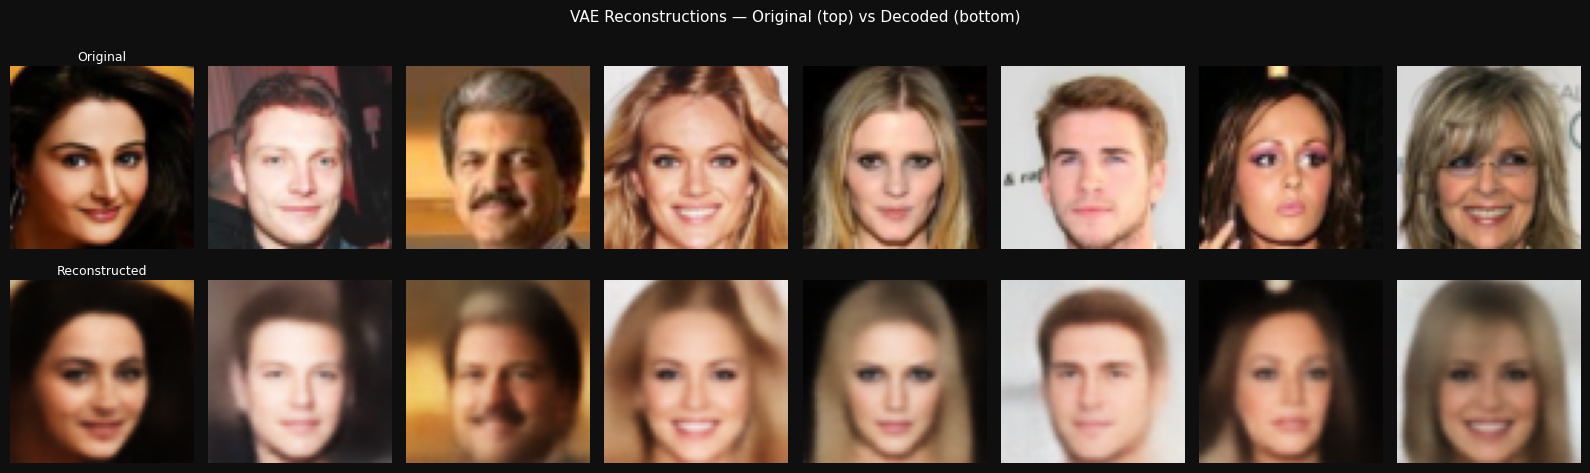

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Load model back cleanly
eval_model = VAE(latent_dim=128).to(device)

# Handle DataParallel saved weights
state = torch.load('/kaggle/working/vae_celeba.pth', map_location=device)
if any(k.startswith('module.') for k in state.keys()):
    state = {k.replace('module.', ''): v for k, v in state.items()}
eval_model.load_state_dict(state)
eval_model.eval()

def denormalize(tensor):
    # [-1,1] → [0,1] for display
    return (tensor * 0.5 + 0.5).clamp(0, 1)

# Grab one batch
imgs = next(iter(dataloader))[:8].to(device)

with torch.no_grad():
    recon, mu, logvar = eval_model(imgs)

# Plot original vs reconstruction
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.patch.set_facecolor('#0f0f0f')

for i in range(8):
    # Original
    orig = denormalize(imgs[i]).cpu().permute(1, 2, 0).numpy()
    axes[0, i].imshow(orig)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', color='white', fontsize=9, pad=4)

    # Reconstruction
    rec = denormalize(recon[i]).cpu().permute(1, 2, 0).numpy()
    axes[1, i].imshow(rec)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', color='white', fontsize=9, pad=4)

plt.suptitle('VAE Reconstructions — Original (top) vs Decoded (bottom)',
    color='white', fontsize=11)
plt.tight_layout()
plt.savefig('reconstructions.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## Step 5: Generation & Latent Space Interpolation

- **Generation**: sample random z ~ N(0,1), decode to brand new faces never seen in training
- **Interpolation**: encode two real faces to z1 and z2, then walk linearly from z1 → z2 in latent space and decode each step — this only works if the latent space is smooth and continuous (which KL divergence enforces)

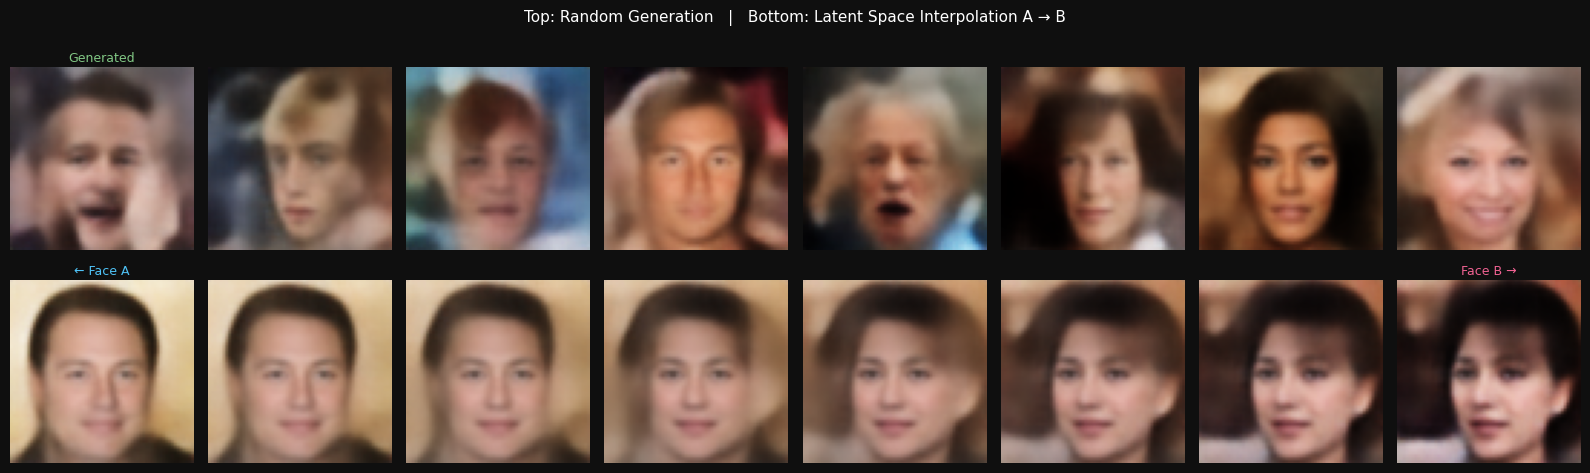

In [10]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.patch.set_facecolor('#0f0f0f')

eval_model.eval()

# ---- Row 1: Pure random generation ----
with torch.no_grad():
    z_random = torch.randn(8, 128).to(device)
    generated = eval_model.module.decoder(z_random) if hasattr(eval_model, 'module') else eval_model.decoder(z_random)

for i in range(8):
    img = denormalize(generated[i]).cpu().permute(1, 2, 0).numpy()
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Generated', color='#81c784', fontsize=9, pad=4)

# ---- Row 2: Latent interpolation between two real faces ----
imgs_batch = next(iter(dataloader)).to(device)
img_a = imgs_batch[0:1]   # face A
img_b = imgs_batch[7:8]   # face B

with torch.no_grad():
    mu_a, logvar_a = eval_model.module.encoder(img_a) if hasattr(eval_model, 'module') else eval_model.encoder(img_a)
    mu_b, logvar_b = eval_model.module.encoder(img_b) if hasattr(eval_model, 'module') else eval_model.encoder(img_b)

    # Interpolate: z = (1-t)*z_a + t*z_b for t in [0,1]
    interp_imgs = []
    for t in np.linspace(0, 1, 8):
        z_interp = (1 - t) * mu_a + t * mu_b
        out = eval_model.module.decoder(z_interp) if hasattr(eval_model, 'module') else eval_model.decoder(z_interp)
        interp_imgs.append(out)

for i, img_t in enumerate(interp_imgs):
    img = denormalize(img_t[0]).cpu().permute(1, 2, 0).numpy()
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('← Face A', color='#4fc3f7', fontsize=9, pad=4)
    if i == 7:
        axes[1, i].set_title('Face B →', color='#f06292', fontsize=9, pad=4)

plt.suptitle('Top: Random Generation   |   Bottom: Latent Space Interpolation A → B',
    color='white', fontsize=11)
plt.tight_layout()
plt.savefig('generation_interpolation.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## Step 6: Training Loss Curves
Visualizing how reconstruction loss and KL divergence evolved across epochs.

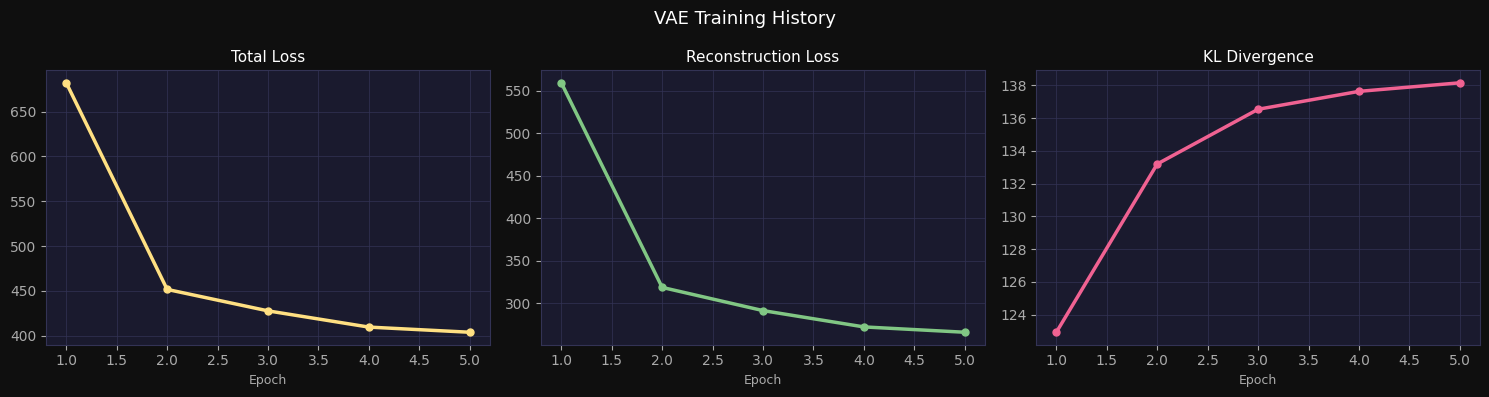

VAE TRAINING SUMMARY
Architecture  : Convolutional VAE
Dataset       : CelebA (202,599 faces)
Image size    : 64 x 64 x 3
Latent dim    : 128
Parameters    : 2,957,251
Epochs        : 5
Final loss    : 403.97
Final recon   : 265.81
Final KL      : 138.16
Saved at      : /kaggle/working/vae_celeba.pth

Key observations:
  Reconstructions : Blurry but identity-preserving (expected for VAE)
  Generation      : Diverse, realistic-looking new faces
  Interpolation   : Smooth morphing proves continuous latent space

Next: CelebA-HQ Diffusion Model (DDPM) for sharp generations


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#0f0f0f')

epochs = range(1, len(history['total']) + 1)
configs = [
    ('total', 'Total Loss',         '#ffe082'),
    ('recon', 'Reconstruction Loss','#81c784'),
    ('kl',    'KL Divergence',      '#f06292'),
]

for ax, (key, title, color) in zip(axes, configs):
    ax.set_facecolor('#1a1a2e')
    ax.plot(epochs, history[key], color=color, linewidth=2.5, marker='o', markersize=5)
    ax.set_title(title, color='white', fontsize=11)
    ax.set_xlabel('Epoch', color='#aaaaaa', fontsize=9)
    ax.tick_params(colors='#aaaaaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')
    ax.grid(True, color='#333355', linewidth=0.5)

plt.suptitle('VAE Training History', color='white', fontsize=13)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Final summary
print("=" * 50)
print("VAE TRAINING SUMMARY")
print("=" * 50)
print(f"Architecture  : Convolutional VAE")
print(f"Dataset       : CelebA (202,599 faces)")
print(f"Image size    : 64 x 64 x 3")
print(f"Latent dim    : 128")
print(f"Parameters    : 2,957,251")
print(f"Epochs        : {len(history['total'])}")
print(f"Final loss    : {history['total'][-1]:.2f}")
print(f"Final recon   : {history['recon'][-1]:.2f}")
print(f"Final KL      : {history['kl'][-1]:.2f}")
print(f"Saved at      : /kaggle/working/vae_celeba.pth")
print("=" * 50)
print("\nKey observations:")
print("  Reconstructions : Blurry but identity-preserving (expected for VAE)")
print("  Generation      : Diverse, realistic-looking new faces")
print("  Interpolation   : Smooth morphing proves continuous latent space")
print("\nNext: CelebA-HQ Diffusion Model (DDPM) for sharp generations")